# Clustering

Clustering is an unsupervised machine learning technique used to group similar data points together without using labelled data. It helps discover hidden patterns or natural groupings in datasets by placing similar data points into the same cluster.

+ Discover the natural grouping or structure in unlabelled data without predefined categories.
+ Data points are assigned to clusters based on similarity or distance measures.
+ Uses Euclidean distance, cosine similarity or other metrics depending on data type and clustering method.
    
*From sklearn documentation*
<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png">

In [ ]:
import seaborn as sns
import pandas as pd

In [ ]:
dataset = sns.load_dataset("penguins")
print(dataset.shape)

dataset = dataset.dropna()
print(dataset.shape)

(344, 7)
(333, 7)


In [ ]:
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
dataset.groupby(["species", "sex"]).agg({"bill_length_mm": "count"})

bill_length_mm
species   sex                   
Adelie    Female              73
          Male                73
Chinstrap Female              34
          Male                34
Gentoo    Female              58
          Male                61

In [ ]:
dataset.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
sc.fit(dataset.select_dtypes("number"))

StandardScaler()

In [ ]:
X = sc.transform(dataset.select_dtypes("number"))
X = pd.DataFrame(X)
X.columns = dataset.select_dtypes("number").columns

In [ ]:
X.describe().round(3)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000,333.000,333.000,333.000
mean,0.000,0.000,0.000,-0.000
std,1.002,1.002,1.002,1.002
min,-2.178,-2.067,-2.070,-1.874
25%,-0.823,-0.796,-0.784,-0.817
50%,0.093,0.069,-0.283,-0.195
75%,0.844,0.781,0.860,0.706
max,2.858,2.205,2.146,2.603


## K-means

The algorithm will categorize the items into k groups or clusters of similarity. To calculate that similarity we will use the Euclidean distance as a measurement. The algorithm works as follows:  
+ Initialization: We begin by randomly selecting k cluster centroids.
+ Assignment Step: Each data point is assigned to the nearest centroid, forming clusters.
+ Update Step: After the assignment, we recalculate the centroid of each cluster by averaging the points within it.
+ Repeat: This process repeats until the centroids no longer change or the maximum number of iterations is reached.

The goal is to partition the dataset into k clusters such that data points within each cluster are more similar to each other than to those in other clusters.



<img src="https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif" width=400>

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters=3, random_state=1)

In [ ]:
model.fit(X)

KMeans(n_clusters=3, random_state=1)

In [ ]:
clusters = model.predict(X)

In [ ]:
def clusters_stats(clusters):

    # делаем копию датасета и сохраняем метки кластеров туда
    data_with_labels = dataset.copy()
    data_with_labels["cluster"] = clusters

    # смотрим сочетания меток видов и кластеров
    data_with_labels["i"] = 1
    print(data_with_labels.pivot_table(index="species", columns="cluster", values="i", aggfunc="sum").fillna(""))
    print("-" * 50)

    # смотрим сочетания меток видов + гендер и кластеров
    print(data_with_labels.pivot_table(index=["species", "sex"], columns="cluster", values="i", aggfunc="sum").fillna(""))

In [ ]:
clusters_stats(clusters)

cluster        0      1     2
species                      
Adelie     124.0         22.0
Chinstrap    5.0         63.0
Gentoo            119.0      
--------------------------------------------------
cluster              0     1     2
species   sex                     
Adelie    Female  73.0            
          Male    51.0        22.0
Chinstrap Female   5.0        29.0
          Male                34.0
Gentoo    Female        58.0      
          Male          61.0      


In [ ]:
real_numbers = sc.inverse_transform(model.cluster_centers_)

pd.DataFrame(real_numbers, columns=X.columns)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,38.276744,18.121705,188.627907,3593.798450
1,47.568067,14.996639,217.235294,5092.436975
2,47.662353,18.748235,196.917647,3898.235294


### The Elbow Method

is used to find the optimal number of clusters (k) in K-Means by analyzing how the clustering performance changes with different k values.


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
distortions = []
cluster_range = range(1, 21)
for k in cluster_range:
    model = KMeans(n_clusters=k)
    model.fit(X)
    distortions.append(model.inertia_)

Text(0, 0.5, 'Within-Cluster Sum of Squares')

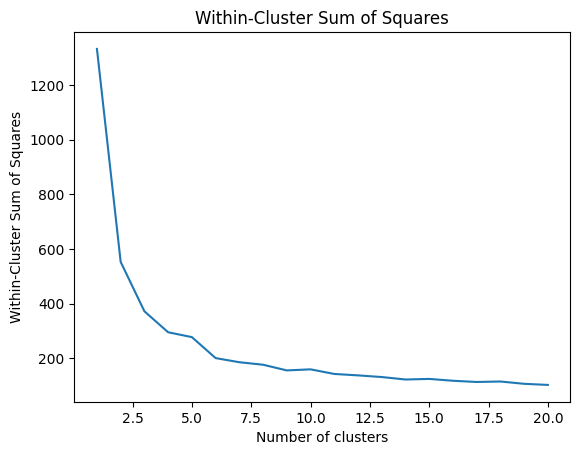

In [ ]:
sns.lineplot(x=cluster_range, y=distortions)
plt.title("Within-Cluster Sum of Squares")
plt.xlabel("Number of clusters")
plt.ylabel("Within-Cluster Sum of Squares")

## Hierarchical Clustering

is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters. Does not require pre‑selecting the number of clusters.



*Источник: [dashee87.github.io](https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/)*

<img src="https://dashee87.github.io/images/hierarch.gif">

*Источник: Википедия*
<div class="row">
    <div class="col-md-6">
        <img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Hierarchical_clustering_simple_diagram.svg">
    </div>
    <div class="col-md-6">
        <img src="https://upload.wikimedia.org/wikipedia/commons/1/12/Iris_dendrogram.png">
    </div>
</div>



**sklearn**

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
model = AgglomerativeClustering(n_clusters=3)

model.fit(X)

AgglomerativeClustering(n_clusters=3)

In [ ]:
clusters = model.labels_
clusters_stats(clusters)

cluster        0      1     2
species                      
Adelie            146.0      
Chinstrap          11.0  57.0
Gentoo     119.0             
--------------------------------------------------
cluster              0     1     2
species   sex                     
Adelie    Female        73.0      
          Male          73.0      
Chinstrap Female        11.0  23.0
          Male                34.0
Gentoo    Female  58.0            
          Male    61.0            


**scipy**

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

In [ ]:
indices = np.random.choice(dataset.shape[0], size=30)

In [ ]:
Z = linkage(X.iloc[indices], method='ward', metric="euclidean")
labels=(dataset["species"] + "|" + dataset["sex"]).iloc[indices].tolist()

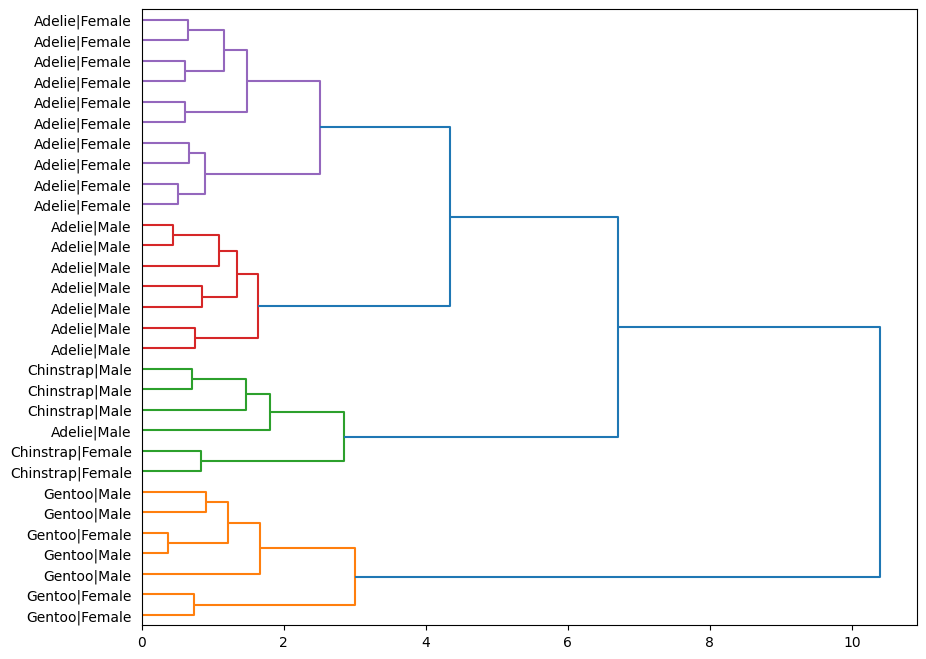

In [ ]:
fig = plt.figure(figsize=(10, 8))
dn = dendrogram(Z, orientation='right', labels=labels, color_threshold=4)
plt.show()

## Practice


In [ ]:
from sklearn.datasets import fetch_20newsgroups

In [ ]:
dataset = fetch_20newsgroups()

In [ ]:
dataset.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [ ]:
target_names = dataset["target_names"]

dataset = pd.DataFrame({"text": dataset["data"], "label": dataset["target"]})

In [ ]:
#dataset = dataset.sample(500)

In [ ]:
dataset.head()

,text,label
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


### Data preparation

Vectorize the data using tf-idf, restrict the number of features (words) by 1000 or 10000.

### Text Clusterization

### K-means

chose k and clusterize

**Keywords**


Find words with highest tf-idf for each cluster

### Hierarchical clustering